IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOCAL DATASET

In [2]:
df = pd.read_csv('quikr_car.csv')
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [4]:
import pandas as pd

df = pd.read_csv('quikr_car.csv')
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


DATA CLEANING

In [5]:
# Remove rows where Price is not available
df = df[df['Price'] != 'Ask For Price']

# Clean Price
df['Price'] = df['Price'].astype(str).str.replace(',', '')
df['Price'] = df['Price'].astype(int)

# Clean year
df = df[df['year'].astype(str).str.isnumeric()]
df['year'] = df['year'].astype(int)

# Clean kms_driven
df = df[df['kms_driven'].notnull()]
df['kms_driven'] = df['kms_driven'].astype(str)

# Keep only rows with numbers
df = df[df['kms_driven'].str.contains(r'\d')]

# Extract numeric value
df['kms_driven'] = df['kms_driven'].str.replace(',', '')
df['kms_driven'] = df['kms_driven'].str.extract(r'(\d+)')

df['kms_driven'] = df['kms_driven'].astype(int)

# Clean fuel_type
df = df[df['fuel_type'].notnull()]

# Keep required columns
df = df[['company', 'year', 'Price', 'kms_driven', 'fuel_type']]

# Reset index
df = df.reset_index(drop=True)

In [9]:
import pandas as pd

df = pd.read_csv('quikr_car.csv')

# Cleaning
df = df[df['Price'] != 'Ask For Price']
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(int)

df = df[df['year'].astype(str).str.isnumeric()]
df['year'] = df['year'].astype(int)

df = df[df['kms_driven'].notnull()]
df['kms_driven'] = df['kms_driven'].astype(str)
df = df[df['kms_driven'].str.contains(r'\d')]
df['kms_driven'] = df['kms_driven'].str.replace(',', '')
df['kms_driven'] = df['kms_driven'].str.extract(r'(\d+)').astype(int)

df = df[df['fuel_type'].notnull()]
df = df[['company', 'year', 'Price', 'kms_driven', 'fuel_type']]
df = df.reset_index(drop=True)

GRAPH
1 PRICE DISTRIBUTION

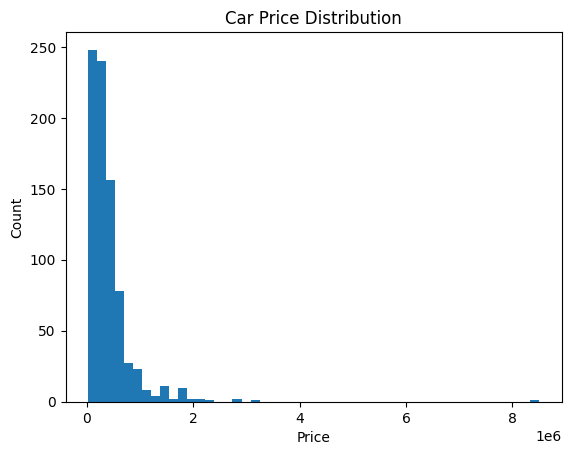

In [9]:
plt.hist(df['Price'], bins=50)
plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

2 CARS BY COMPANY

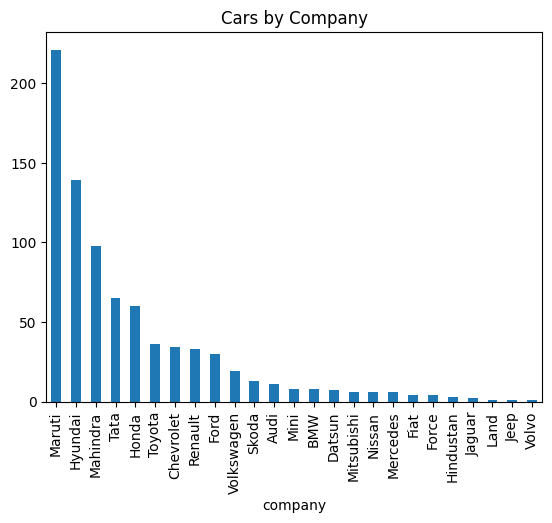

In [10]:
df['company'].value_counts().plot(kind='bar')
plt.title("Cars by Company")
plt.show()

3 FUEL TYPE PIE CHART

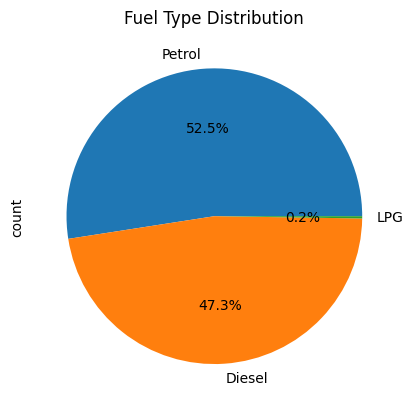

In [11]:
df['fuel_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Fuel Type Distribution")
plt.show()

4 YEAR VS PRICE

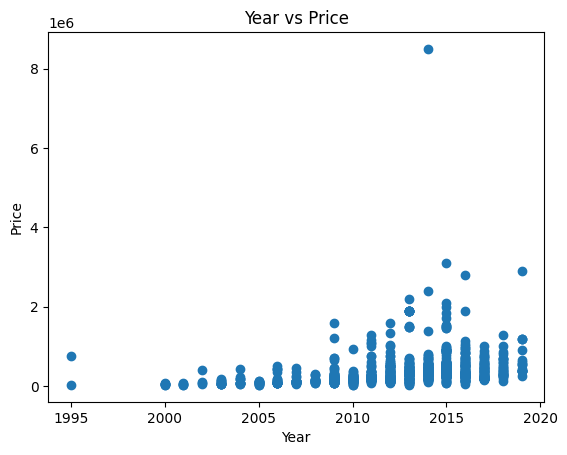

In [12]:
plt.scatter(df['year'], df['Price'])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")
plt.show()

STEP 5 CONVERT DATA 

In [7]:
df = pd.get_dummies(df, drop_first=True)

STEP 6 DEFINE X AND Y

In [8]:
X = df.drop('Price', axis=1)
y = df['Price']

STEP 7 TRAIN  TEST SPLIT

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

STEP 8 TRAIN MODEL

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


STEP 9 ACCURACY

In [17]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.1877654982563569


STEP 10 SAVE MODEL

In [13]:
import pickle

pickle.dump(model, open('car_price_model.pkl', 'wb'))